Zeilen für Syrien ab 2010 vor weiterer Bereinigung: 2989


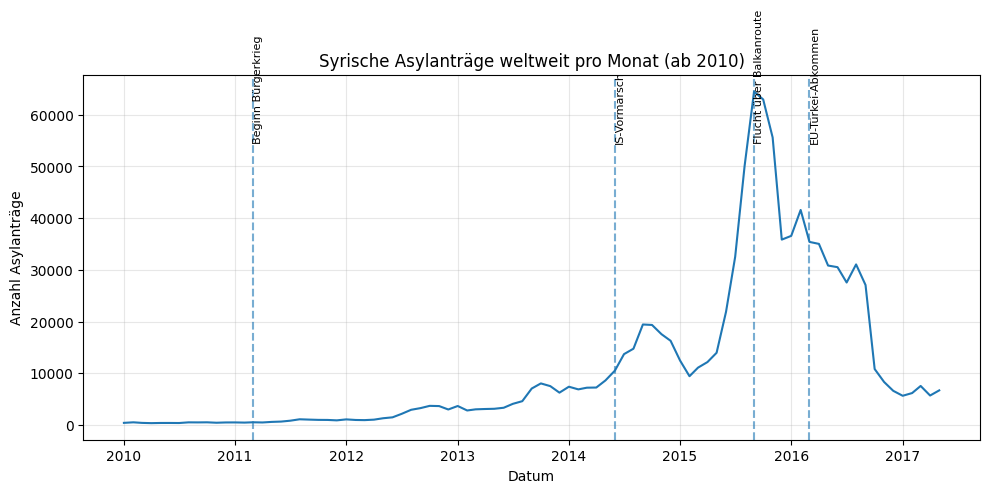

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

ORIGIN = "Syrian Arab Rep."
YEAR_MIN = 2010

def load_asylum_data(path):
    df = pd.read_csv(path, dtype=str)
    df["Origin"] = df["Origin"].str.strip()
    df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
    df["Value"] = (
        df["Value"]
        .str.replace(",", "", regex=False)
        .str.strip()
    )
    df["Value"] = pd.to_numeric(df["Value"], errors="coerce")
    return df


asylum_seekers = load_asylum_data("../archive/asylum_seekers_monthly.csv")

mask = (asylum_seekers["Origin"] == ORIGIN) & (asylum_seekers["Year"] >= YEAR_MIN)
asylum_seekers_syr = asylum_seekers.loc[mask].copy()

print("Zeilen für Syrien ab 2010 vor weiterer Bereinigung:", len(asylum_seekers_syr))

asylum_seekers_syr["Date"] = pd.to_datetime(
    asylum_seekers_syr["Year"].astype(int).astype(str) + "-" +
    asylum_seekers_syr["Month"].astype(str).str.zfill(2) + "-01",
    errors="coerce"
)

asylum_seekers_syr = asylum_seekers_syr.dropna(subset=["Date", "Value"])

monthly_trend = (
    asylum_seekers_syr
    .groupby("Date")["Value"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_trend["Date"], monthly_trend["Value"], linewidth=1.5)
plt.title("Syrische Asylanträge weltweit pro Monat (ab 2010)")
plt.xlabel("Datum")
plt.ylabel("Anzahl Asylanträge")
plt.grid(True, alpha=0.3)

events = {
    "2011-03": "Beginn Bürgerkrieg",
    "2014-06": "IS-Vormarsch",
    "2015-09": "Flucht über Balkanroute",
    "2016-03": "EU-Türkei-Abkommen",
}

for date_str, label in events.items():
    date = pd.to_datetime(date_str + "-01")
    plt.axvline(x=date, linestyle="--", alpha=0.6)
    plt.text(
        date,
        monthly_trend["Value"].max() * 0.85,
        label,
        rotation=90,
        fontsize=8
    )

plt.tight_layout()
plt.show()


Gesamtzeilen: 2892
Fehlerhafte Zeilen (NaN): 0
Anteil fehlerhafter Zeilen: 0.00%


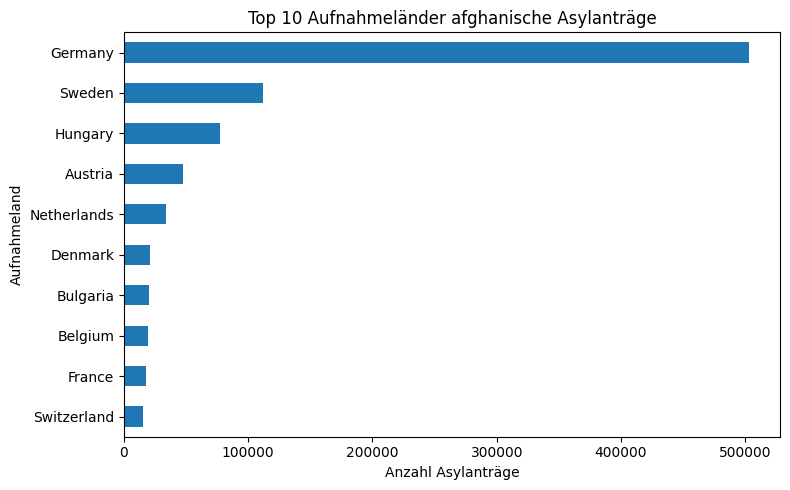

In [11]:
total_rows = len(asylum_seekers_syr)
invalid_rows = asylum_seekers_syr["Value"].isna().sum()
invalid_percent = (invalid_rows / total_rows) * 100

print(f"Gesamtzeilen: {total_rows}")
print(f"Fehlerhafte Zeilen (NaN): {invalid_rows}")
print(f"Anteil fehlerhafter Zeilen: {invalid_percent:.2f}%")

top_countries = (
    asylum_seekers_syr
    .groupby("Country / territory of asylum/residence")["Value"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(8, 5))
top_countries.sort_values().plot(kind="barh")
plt.title("Top 10 Aufnahmeländer afghanische Asylanträge")
plt.xlabel("Anzahl Asylanträge")
plt.ylabel("Aufnahmeland")
plt.tight_layout()
plt.show()


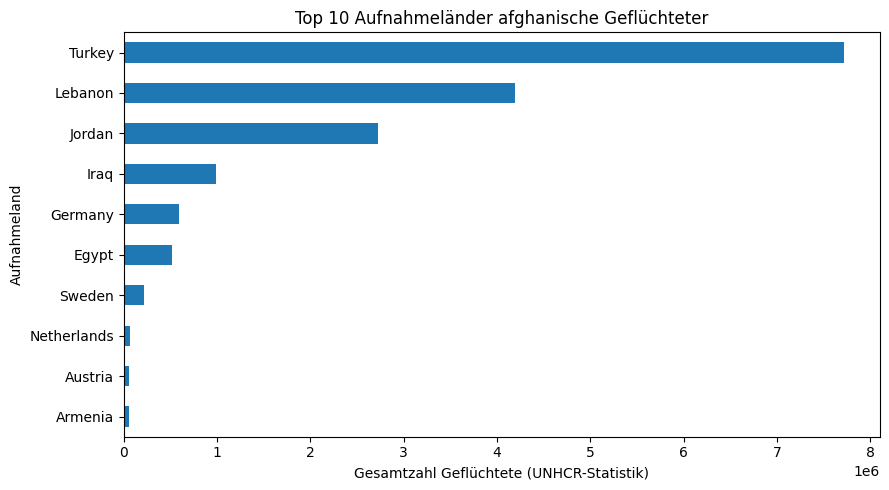

In [12]:
# ---------- Personen-Daten laden ----------
persons = pd.read_csv("../archive/persons_of_concern.csv", dtype=str)

persons["Year"] = pd.to_numeric(persons["Year"], errors="coerce")
persons["Refugees (incl. refugee-like situations)"] = pd.to_numeric(
    persons["Refugees (incl. refugee-like situations)"],
    errors="coerce"
)

mask = (persons["Origin"] == ORIGIN) & (persons["Year"] >= YEAR_MIN)
syr_refugees = persons.loc[mask]

top_hosts = (
    syr_refugees
    .groupby("Country / territory of asylum/residence")["Refugees (incl. refugee-like situations)"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(9, 5))
top_hosts.sort_values().plot(kind="barh")
plt.title("Top 10 Aufnahmeländer afghanische Geflüchteter")
plt.xlabel("Gesamtzahl Geflüchtete (UNHCR-Statistik)")
plt.ylabel("Aufnahmeland")
plt.tight_layout()
plt.show()
